# CUAD: Data Loading, Inspection and Cleaning

**Stage 1 of the Accenture contract review challenge.**

Goal of this notebook: take the raw CUAD JSON and turn it into three clean tables the
rest of the team can build on, while documenting what the data actually looks like.

Output:

| file | one row per | used for |
|---|---|---|
| `contracts.parquet` | contract | chunking, contract-level features |
| `spans.parquet` | annotated clause span | model training, clause inspection |
| `grid.parquet` | contract x category | class imbalance, missing-clause risk signal |

---
## 0. Setup

In [1]:
import json
import itertools
import re
import unicodedata
from pathlib import Path

import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

RAW_DIR = Path("../data")
OUT_DIR = Path("../data/interim")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1. What is in the file?

CUAD ships as one JSON file. Not a table, so pandas cannot read it directly
(`pd.read_json` gives you a column full of dicts, which is useless). We walk the
nesting by hand first.

In [2]:
with open(RAW_DIR / "CUADv1.json") as f:
    cuad = json.load(f)

print("top level keys:", list(cuad.keys()))
print("version:", cuad["version"])
print("number of contracts:", len(cuad["data"]))

top level keys: ['version', 'data']
version: aok_v1.0
number of contracts: 510


`version` is metadata. Everything we care about is in `data`, a list of 510 contracts.

**Note on which file to use.** The project overview says the pipeline should run on the
official Atticus splits, `train_separate_questions.json` (408 contracts) and `test.json`
(102), and that we must not re-split ourselves. `CUADv1.json` is all 510 in one file and
is convenient for exploring. The code in this notebook works on any of the three since
the structure is identical, which we verify at the end.

---
## 2. One contract

Each item in `data` is a single contract with exactly two keys.

In [3]:
entry = cuad["data"][0]

print("keys:", list(entry.keys()))
print("title:", entry["title"])

keys: ['title', 'paragraphs']
title: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT


The title encodes the SEC filing: company, filing date, exhibit number, and document type.
This is a distributor agreement filed by Lime Energy Co in September 1999.

---
## 3. The `paragraphs` quirk

`paragraphs` sounds like it should be a list of paragraphs. It isn't.

In [4]:
paras = entry["paragraphs"]

print("type:", type(paras))
print("length:", len(paras))
print("keys of paras[0]:", list(paras[0].keys()))

type: <class 'list'>
length: 1
keys of paras[0]: ['qas', 'context']


It is **always a list of length 1**, and the single item holds the entire contract.

The reason: CUAD is packaged in **SQuAD 2.0 format**, a reading-comprehension format from
2018 where you get a passage plus questions about it. CUAD reused that container, which is
why the field names describe reading comprehension rather than contracts:

| SQuAD field | what it means in CUAD |
|---|---|
| `paragraphs` | always exactly 1, holds the whole contract |
| `context` | the full contract text |
| `qas` | the 41 clause categories |
| `answers` | the spans a lawyer highlighted |
| `is_impossible` | that clause type is absent from this contract |

We assert the length-1 assumption later rather than trusting it.

---
## 4. `context`: the contract text

One string containing the whole document.

In [5]:
context = paras[0]["context"]

print("type:", type(context))
print("length:", f"{len(context):,} characters")
print()
print(context[:600])

type: <class 'str'>
length: 54,290 characters

EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.

                                    RECITALS

         A. The  Company's  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an "Energy  Saver"  which may be improved  or  otherwise  changed  from its present composition (the "P


Two things to notice in that preview, both of which matter for cleaning:

1. **Runs of whitespace.** `The  Company's  Business` has double spaces, and lines are
   indented with long runs of spaces. The source was a fixed-width plain-text SEC filing.
2. **Page furniture.** Scroll further into the document and you will find `Page -2-`,
   `Page -3-` and so on landing mid-sentence, plus `EXHIBIT 10.6` headers.

In [6]:
# page break artifacts, scattered through the text
for m in re.finditer(r"Page -\d+-", context):
    print(m.start(), repr(context[m.start():m.start()+10]))

8237 'Page -2-\n\n'
11054 'Page -3-\n\n'
15578 'Page -4-\n\n'
19680 'Page -5-\n\n'
23661 'Page -6-\n\n'
27782 'Page -7-\n\n'
31796 'Page -8-\n\n'
36563 'Page -9-\n\n'
40581 'Page -10-\n'
44866 'Page -11-\n'
49216 'Page -12-\n'
51668 'Page -13-\n'
54281 'Page -14-'


---
## 5. `qas`: the 41 clause categories

This is the annotation layer. Lawyers read each contract and marked, for each of 41 clause
types, every passage belonging to that type.

In [7]:
qas = paras[0]["qas"]

print("number of qas:", len(qas))
print("keys of one qa:", list(qas[0].keys()))

number of qas: 41
keys of one qa: ['answers', 'id', 'question', 'is_impossible']


### One qa, pulled apart

In [8]:
qa = qas[0]

print("id:          ", qa["id"])
print("question:    ", qa["question"][:100], "...")
print("is_impossible:", qa["is_impossible"])
print("answers:     ", qa["answers"])

id:           LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name
question:     Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by  ...
is_impossible: False
answers:      [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}]


Read that as: *a lawyer marked the text `DISTRIBUTOR AGREEMENT`, starting at character 44,
as a Document Name clause.*

- `id` is always `{title}__{Category}`, so splitting on `__` is the cleanest way to get the
  category. Easier than regexing the long question string.
- `question` is boilerplate wrapped around the category name. Only the quoted part matters.
- `answers` is a list of **spans**. Zero, one, or several.
- `is_impossible` is just shorthand for `len(answers) == 0`.

### Terminology

Three words for the same object, because three sources named it differently:

| word | used by |
|---|---|
| **answer** | the JSON keys (SQuAD legacy) |
| **span** | the CUAD paper, and NLP generally |
| highlight | informal |

We use **span** everywhere in code and in the writeup.

### The offsets are real character positions

`answer_start` is an index into *this contract's* `context` string. Proving it:

In [9]:
ans = qa["answers"][0]
s = ans["answer_start"]
e = s + len(ans["text"])

print("recorded text:", repr(ans["text"]))
print("sliced text:  ", repr(context[s:e]))
print("match:", context[s:e] == ans["text"])

recorded text: 'DISTRIBUTOR AGREEMENT'
sliced text:   'DISTRIBUTOR AGREEMENT'
match: True


This is the single most important property of the dataset, and the reason cleaning is
dangerous. **Any operation that changes the length of `context` invalidates all 13,823
offsets silently.** No error, the spans just start pointing at the wrong text.

We come back to this in section 9.

---
## 6. Most categories are empty

A distributor agreement has no IP assignment clause, so that category comes back empty.
Looking at all 41 for this one contract:

In [10]:
present, absent = [], []

for qa in qas:
    cat = qa["id"].split("__")[-1]
    n = len(qa["answers"])
    (present if n else absent).append((cat, n))

print(f"PRESENT ({len(present)} categories)")
for cat, n in sorted(present, key=lambda x: -x[1]):
    print(f"  {n:>2}  {cat}")

print(f"\nABSENT ({len(absent)} categories)")
for cat, _ in absent:
    print(f"      {cat}")

PRESENT (19 categories)
   8  Warranty Duration
   5  Parties
   5  Minimum Commitment
   4  Post-Termination Services
   3  Exclusivity
   3  Rofr/Rofo/Rofn
   2  Effective Date
   2  No-Solicit Of Customers
   2  Anti-Assignment
   2  Price Restrictions
   2  License Grant
   1  Document Name
   1  Agreement Date
   1  Expiration Date
   1  Renewal Term
   1  Governing Law
   1  No-Solicit Of Employees
   1  Insurance
   1  Covenant Not To Sue

ABSENT (22 categories)
      Notice Period To Terminate Renewal
      Most Favored Nation
      Non-Compete
      Competitive Restriction Exception
      Non-Disparagement
      Termination For Convenience
      Change Of Control
      Revenue/Profit Sharing
      Volume Restriction
      Ip Ownership Assignment
      Joint Ip Ownership
      Non-Transferable License
      Affiliate License-Licensor
      Affiliate License-Licensee
      Unlimited/All-You-Can-Eat-License
      Irrevocable Or Perpetual License
      Source Code Escrow
      Aud

Roughly half the categories are empty for this contract, and it varies by document type.
Aggregated over 510 contracts, this is the **class imbalance** the success criteria warn
about, and why accuracy is a misleading metric here: a model that predicts "absent" for
everything would score well and be worthless.

We quantify this properly in section 8 once the grid table exists.

---
## 7. Finding: the task is genuinely multi-label

The same passage can carry more than one category. Checking for spans that share an offset:

In [11]:
from collections import defaultdict

by_offset = defaultdict(list)
for qa in qas:
    cat = qa["id"].split("__")[-1]
    for a in qa["answers"]:
        by_offset[a["answer_start"]].append(cat)

for start, cats in by_offset.items():
    if len(cats) > 1:
        print(f"offset {start}: {cats}")
        print(f"  {context[start:start+110]!r}")
        print()

offset 5268: ['Effective Date', 'Expiration Date']
  'The term of this  Agreement  shall be ten (10)                            years (the "Term")  which shall  com'

offset 2112: ['Exclusivity', 'License Grant']
  "Company  hereby   appoints                            Distributor as Company's exclusive distributor within   "



**Implication for the model workstream:** one chunk of text can be several categories at
once, so this is multi-label, not multi-class. That means sigmoid outputs with binary
cross-entropy, not softmax, and a per-category threshold rather than an argmax.

**Implication for chunking:** a chunk's label is a 41-dimensional binary vector, not a
single class id.

Worth flagging to the team.

---
## 8. Build the tables

Now that the structure is clear, flatten it. Three levels of nesting means three loops:

```
contract  ->  41 categories  ->  0 or more spans
```

### 8.1 `contracts` — one row per contract

The text is kept **byte-for-byte identical to the source**. This table is the reference
that all offsets point into.

In [12]:
def build_contracts(raw):
    rows = []
    for entry in raw["data"]:
        # verify the length-1 assumption from section 3 rather than trusting it
        assert len(entry["paragraphs"]) == 1, f"unexpected paragraphs: {entry['title']}"
        ctx = entry["paragraphs"][0]["context"]
        rows.append({
            "contract": entry["title"].strip(),
            "text": ctx,
            "n_chars": len(ctx),
        })
    return pd.DataFrame(rows)


contracts = build_contracts(cuad)
print(contracts.shape)
contracts[["contract", "n_chars"]].head()

(510, 3)


,contract,n_chars
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,54290
1,"WHITESMOKE,INC_11_08_2011-EX-10.26-PROMOTION AND DISTRIBUTION AGREEMENT",70383
2,LohaCompanyltd_20191209_F-1_EX-10.16_11917878_EX-10.16_Supply Agreement,11475
3,CENTRACKINTERNATIONALINC_10_29_1999-EX-10.3-WEB SITE HOSTING AGREEMENT,15176
4,NELNETINC_04_08_2020-EX-1-JOINT FILING AGREEMENT,1081


In [13]:
contracts["n_chars"].describe().round(0)

count       510.0
mean      52563.0
std       55946.0
min         645.0
25%       16416.0
50%       33143.0
75%       66395.0
max      338211.0
Name: n_chars, dtype: float64

Contract length varies enormously. The longest documents are far beyond any transformer's
context window, which is the whole reason a chunking strategy is needed in stage 2.

Text(0.5, 0, 'characters')

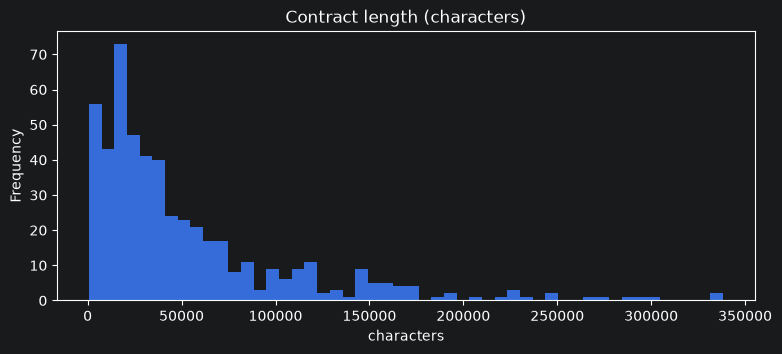

In [14]:
ax = contracts["n_chars"].plot.hist(bins=50, figsize=(9, 3.5), title="Contract length (characters)")
ax.set_xlabel("characters")

### 8.2 `spans` — one row per annotated span

Note the innermost loop does nothing when `answers` is empty, so absent categories simply
produce no rows. That is intentional and it is why we also need the grid in 8.3.

In [15]:
def build_spans(raw):
    rows = []
    for entry in raw["data"]:
        title = entry["title"].strip()
        ctx = entry["paragraphs"][0]["context"]

        for qa in entry["paragraphs"][0]["qas"]:
            category = qa["id"].split("__")[-1].strip()

            for a in qa["answers"]:
                start = a["answer_start"]
                text = a["text"]
                rows.append({
                    "contract": title,
                    "category": category,
                    "text": text,
                    "start": start,
                    "end": start + len(text),
                    "n_chars_span": len(text),
                    "rel_position": start / len(ctx),   # where in the doc, 0 to 1
                })
    return pd.DataFrame(rows)


spans = build_spans(cuad)
print(spans.shape)
spans.head()

(13823, 7)


,contract,category,text,start,end,n_chars_span,rel_position
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Document Name,DISTRIBUTOR AGREEMENT,44,65,21,0.000810
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Parties,Distributor,244,255,11,0.004494
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Parties,Electric City Corp.,148,167,19,0.002726
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Parties,Electric City of Illinois L.L.C.,49574,49606,32,0.913133
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Parties,Company,197,204,7,0.003629


The paper reports **13,823 annotated spans**. Checking against that number is a free
correctness test on the loading code.

In [16]:
print("spans loaded:", len(spans))
print("paper reports: 13,823")
print("match:", len(spans) == 13823)
print()
print("distinct categories:", spans["category"].nunique(), "(expect 41)")
print("distinct contracts with >=1 span:", spans["contract"].nunique())

spans loaded: 13823
paper reports: 13,823
match: True

distinct categories: 41 (expect 41)
distinct contracts with >=1 span: 510


### 8.3 `grid` — every contract x category pair, including the zeros

`spans` cannot answer *"which contracts are missing a liability cap?"*, because absence is
not a row. You cannot filter for something that does not exist.

That absence matters twice over in this project:

- **Class imbalance** requires counting the zeros to get a per-category presence rate.
- **Risk scoring**: the advisor guidance explicitly lists missing expected clauses as a
  risk signal. A supply agreement with no liability cap is riskier than one with a cap.

So we build the complete grid: 510 contracts x 41 categories = 20,910 rows.

In [17]:
def build_grid(contracts, spans):
    titles = contracts["contract"].tolist()
    categories = sorted(spans["category"].unique())

    grid = pd.DataFrame(
        itertools.product(titles, categories),
        columns=["contract", "category"],
    )
    counts = spans.groupby(["contract", "category"]).size().rename("n_spans")
    grid = grid.merge(counts, on=["contract", "category"], how="left")
    grid["n_spans"] = grid["n_spans"].fillna(0).astype(int)
    grid["has_clause"] = grid["n_spans"] > 0
    return grid


grid = build_grid(contracts, spans)
print(grid.shape, "expected", len(contracts) * spans["category"].nunique())
grid.head()

(20910, 4) expected 20910


,contract,category,n_spans,has_clause
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Affiliate License-Licensee,0,False
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Affiliate License-Licensor,0,False
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Agreement Date,1,True
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Anti-Assignment,2,True
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT,Audit Rights,0,False


The `how="left"` join plus `fillna(0)` is the whole trick: the left join keeps every grid
row even when nothing matched, and the unmatched counts become zeros.

---
## 9. Class imbalance

Now we can answer the question that motivates the whole evaluation strategy.

In [18]:
coverage = (
    grid.groupby("category")["has_clause"]
    .agg(n_contracts="sum", pct_contracts="mean")
    .assign(pct_contracts=lambda d: (d["pct_contracts"] * 100).round(1))
    .sort_values("n_contracts", ascending=False)
)
coverage

,n_contracts,pct_contracts
category,,
Document Name,510,100.0
Parties,509,99.8
Agreement Date,470,92.2
Governing Law,437,85.7
Expiration Date,413,81.0
Effective Date,390,76.5
Anti-Assignment,374,73.3
Cap On Liability,275,53.9
License Grant,255,50.0


Text(0.5, 0, '% of 510 contracts')

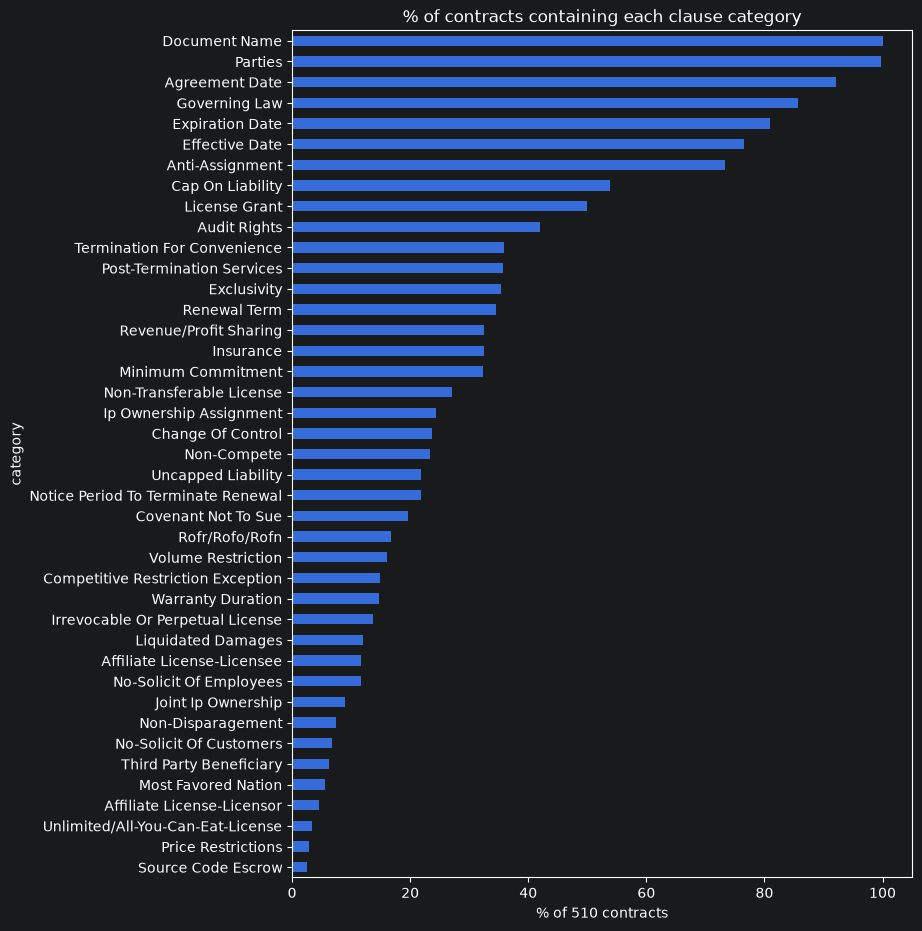

In [19]:
ax = coverage["pct_contracts"].sort_values().plot.barh(
    figsize=(8, 11), title="% of contracts containing each clause category"
)
ax.set_xlabel("% of 510 contracts")

**Read the tail of that chart.** The rarest categories appear in only a handful of the 510
contracts. Those will produce near-zero F1 no matter what the model does, and they belong
in the error analysis section of the final report as a known limitation rather than as a
surprise in November.

In [20]:
print("RAREST 10")
print(coverage.tail(10).to_string())

RAREST 10
                                   n_contracts  pct_contracts
category                                                     
Affiliate License-Licensee                  59           11.6
Joint Ip Ownership                          46            9.0
Non-Disparagement                           38            7.5
No-Solicit Of Customers                     34            6.7
Third Party Beneficiary                     32            6.3
Most Favored Nation                         28            5.5
Affiliate License-Licensor                  23            4.5
Unlimited/All-You-Can-Eat-License           17            3.3
Price Restrictions                          15            2.9
Source Code Escrow                          13            2.5


### The 10 priority categories

The advisor guidance says to scope the initial model to roughly 10 high-value categories
rather than all 41, because many of the 41 are document metadata (Document Name, Parties,
Agreement Date) with no risk content at all.

Mapping the advisor's list onto CUAD's actual category names:

In [21]:
PRIORITY = [
    "Cap On Liability",
    "Uncapped Liability",
    "Governing Law",
    "Anti-Assignment",
    "Change Of Control",
    "Termination For Convenience",
    "Exclusivity",
    "Non-Compete",
    "Renewal Term",
    "Audit Rights",
]

all_cats = set(coverage.index)
print("matched:", [c for c in PRIORITY if c in all_cats])
print("NOT in CUAD:", [c for c in PRIORITY if c not in all_cats])
print()
coverage.loc[[c for c in PRIORITY if c in all_cats]]

matched: ['Cap On Liability', 'Uncapped Liability', 'Governing Law', 'Anti-Assignment', 'Change Of Control', 'Termination For Convenience', 'Exclusivity', 'Non-Compete', 'Renewal Term', 'Audit Rights']
NOT in CUAD: []



,n_contracts,pct_contracts
category,,
Cap On Liability,275,53.9
Uncapped Liability,111,21.8
Governing Law,437,85.7
Anti-Assignment,374,73.3
Change Of Control,121,23.7
Termination For Convenience,183,35.9
Exclusivity,180,35.3
Non-Compete,119,23.3
Renewal Term,176,34.5


Note that CUAD has no single "Indemnification", "Confidentiality" or "Dispute Resolution"
category, which the advisor named. That gap is worth raising at the next check-in: either
we drop them, or we map them to the closest CUAD equivalents. **Open question for the
advisor.**

---
## 10. Cleaning

### The constraint that drives every decision here

From section 5: every annotation is a character offset into `context`. So:

> **Any clean that changes the length of the contract text silently corrupts all 13,823
> annotations.**

Collapsing whitespace, stripping page numbers, dropping headers — all of these shift every
downstream offset and there is no error message when it happens.

**Decision: contract text stays byte-for-byte identical to the source.** Cleaning is
applied to the extracted span text only, into a separate `text_clean` column, with the
original preserved in `text`.

This keeps `contracts.parquet` usable as the reference for stage-2 chunking, which needs
raw offsets to assign labels to chunks.

### 10.1 Deduplicate

Identical annotations do occur. Dedupe on the identity of a span, which is
contract + category + offsets.

In [22]:
before = len(spans)
spans = spans.drop_duplicates(subset=["contract", "category", "start", "end"]).reset_index(drop=True)
print(f"dropped {before - len(spans)} duplicate spans, {len(spans)} remain")

dropped 0 duplicate spans, 13823 remain


### 10.2 Normalize span text

Deliberately **not** lowercasing or stripping punctuation. Legal phrasing carries signal
(`IN NO EVENT SHALL`, section numbering, defined terms in quotes), and the project brief
says to preserve legal terminology. This only fixes formatting damage from the filing
process.

In [23]:
def clean_span_text(s):
    s = unicodedata.normalize("NFKC", s)   # smart quotes, ligatures, nbsp
    s = s.replace("\xa0", " ")
    s = re.sub(r"\s+", " ", s)            # the big fixed-width gaps
    return s.strip()


spans["text_clean"] = spans["text"].map(clean_span_text)

# before / after on a span with heavy formatting damage
worst = spans.loc[spans["text"].str.count(r"\s{4,}").idxmax()]
print("RAW:\n", repr(worst["text"][:400]))
print("\nCLEAN:\n", repr(worst["text_clean"][:400]))

RAW:
 '- ------------------------------------------------------------------------------------------------------------------                                                                Requirement - ------------------------------------------------------------------------------------------------------------------ Characteristic                Bellcore                      CCITT/ITU                     D'

CLEAN:
 '- ------------------------------------------------------------------------------------------------------------------ Requirement - ------------------------------------------------------------------------------------------------------------------ Characteristic Bellcore CCITT/ITU D2 - ------------------------------------------------------------------------------------------------------------------ '


### 10.3 Flag data quality issues

We flag rather than delete, so the EDA can quantify the mess and stage 2 can decide what
to do about it.

In [24]:
REDACTION = re.compile(r"\[\s*\*+\s*\]")

spans["has_redaction"] = spans["text"].str.contains(REDACTION, regex=True)
spans["is_very_short"] = spans["n_chars_span"] < 15
spans["whitespace_ratio"] = (spans["text"].str.count(r"\s") / spans["n_chars_span"].clip(lower=1)).round(3)

print("spans containing [***] redactions:", spans["has_redaction"].sum())
print("spans under 15 chars:            ", spans["is_very_short"].sum())
print("median whitespace ratio:         ", spans["whitespace_ratio"].median())

spans containing [***] redactions: 655
spans under 15 chars:             1446
median whitespace ratio:          0.154


**Redactions matter for risk scoring.** `[***]` is an SEC confidential-treatment blackout,
and it often removes the exact number the risk rule would key on. If a large share of
Cap On Liability spans have the cap amount redacted, a rule like "flag caps below \$1M"
cannot fire. The risk workstream needs to know this now, not in November.

In [25]:
# which categories are most affected by redaction?
red = (
    spans.groupby("category")["has_redaction"]
    .agg(n_redacted="sum", pct="mean")
    .assign(pct=lambda d: (d["pct"] * 100).round(1))
    .sort_values("n_redacted", ascending=False)
    .head(12)
)
red

,n_redacted,pct
category,,
Minimum Commitment,75,17.7
Revenue/Profit Sharing,67,16.0
Post-Termination Services,56,12.4
Audit Rights,48,7.5
Insurance,45,8.0
Cap On Liability,43,6.4
Rofr/Rofo/Rofn,31,8.4
License Grant,31,4.0
Uncapped Liability,25,15.0


In [26]:
# very short spans: are they real clauses or annotation noise?
spans.loc[spans["is_very_short"], ["category", "text"]].head(15)

,category,text
1,Parties,Distributor
4,Parties,Company
47,Parties,Distributor
48,Parties,Google
49,Parties,Google Inc
51,Effective Date,1 August 2011
74,Parties,The seller:
82,Parties,the Customer
83,Parties,i-on
98,Parties,Co-Trustee


### 10.4 Span length by category

Useful input for the chunking decision: if a category's clauses routinely run longer than
the chunk size, a single chunk will only ever see part of one.

In [27]:
length_stats = (
    spans.groupby("category")["n_chars_span"]
    .agg(["count", "median", "mean", "max"])
    .round(0)
    .sort_values("median", ascending=False)
)
length_stats.head(15)

,count,median,mean,max
category,,,,
Affiliate License-Licensor,69,491.0,617.0,2457
Irrevocable Or Perpetual License,165,489.0,566.0,2457
Affiliate License-Licensee,115,484.0,555.0,2457
Uncapped Liability,167,423.0,452.0,1624
Most Favored Nation,38,379.0,454.0,1136
Post-Termination Services,450,368.0,449.0,1778
Competitive Restriction Exception,125,366.0,452.0,2820
License Grant,777,356.0,432.0,2457
Non-Transferable License,298,351.0,421.0,2246


---
## 11. Verification

The critical assertion: does `context[start:end]` reproduce the recorded span text, for
every span in the dataset? If yes, the offsets are trustworthy and stage 2 can rely on
them.

In [28]:
def verify_offsets(contracts, spans):
    lookup = dict(zip(contracts["contract"], contracts["text"]))
    bad = []
    for row in spans.itertuples():
        if lookup[row.contract][row.start:row.end] != row.text:
            bad.append((row.contract, row.category, row.start))
    return bad


bad = verify_offsets(contracts, spans)
print(f"offset mismatches: {len(bad)} / {len(spans)}")
if bad:
    print("first few:", bad[:5])

offset mismatches: 0 / 13823


In [29]:
# remaining sanity checks
print("duplicate contract titles:", contracts["contract"].duplicated().sum())
print("nulls in spans:")
print(spans[["contract", "category", "text", "start"]].isna().sum())
print()
print("grid rows:", len(grid), "expected:", len(contracts) * spans["category"].nunique())
print("negative or out-of-range offsets:", ((spans["start"] < 0)).sum())

duplicate contract titles: 0
nulls in spans:
contract    0
category    0
text        0
start       0
dtype: int64

grid rows: 20910 expected: 20910
negative or out-of-range offsets: 0


### Near-duplicate contracts

Some agreements are filed more than once with minor edits. If near-duplicates land on both
sides of the official train/test split, evaluation leaks. We cannot re-split, but we can
**measure and report** it.

In [30]:
sig = contracts["text"].str[:3000].map(hash)
dupe_groups = sig[sig.duplicated(keep=False)]

print("contracts sharing an identical first 3000 chars:", len(dupe_groups))
if len(dupe_groups):
    display(contracts.loc[dupe_groups.index, ["contract", "n_chars"]].sort_values("contract"))

contracts sharing an identical first 3000 chars: 4


,contract,n_chars
373,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT",12020
367,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT(1)",12020
332,"ARMSTRONGFLOORING,INC_01_07_2019-EX-10.2-INTELLECTUAL PROPERTY AGREEMENT",69759
456,ArmstrongFlooringInc_20190107_8-K_EX-10.2_11471795_EX-10.2_Intellectual Property Agreement,56858


---
# Part 2: the official train / test splits

Everything above ran on `CUADv1.json`, all 510 contracts in one file, which is the
convenient thing to explore. The **pipeline** must run on the official Atticus splits:
`train_separate_questions.json` (408) and `test.json` (102), split at contract level, and
the brief forbids re-splitting them ourselves.

Before porting the loader over, check that the files have the same shape.

---
## 12. Structural check on the split files

In [31]:
for name, expected in [("train_separate_questions.json", 408), ("test.json", 102)]:
    path = RAW_DIR / name
    if not path.exists():
        print(f"{name}: NOT FOUND")
        continue
    with open(path) as f:
        d = json.load(f)
    e = d["data"][0]
    print(f"{name}: {len(d['data'])} contracts (expect {expected}), "
          f"paragraphs={len(e['paragraphs'])}, qas={len(e['paragraphs'][0]['qas'])}")

train_separate_questions.json: 408 contracts (expect 408), paragraphs=1, qas=68
test.json: 102 contracts (expect 102), paragraphs=1, qas=41


### Finding: the train file does not have 41 qas

`test.json` has 41 qas per contract as expected. `train_separate_questions.json` has **68**.

This is what `separate_questions` in the filename means, and it is exactly the kind of
assumption that has to be checked rather than trusted. Running the loader on it unmodified
would produce a category set that silently disagrees with test.

Diagnosing it:

In [32]:
with open(RAW_DIR / "train_separate_questions.json") as f:
    train_raw = json.load(f)
with open(RAW_DIR / "test.json") as f:
    test_raw = json.load(f)

e = train_raw["data"][0]
qas0 = e["paragraphs"][0]["qas"]

cats = [q["id"].split("__")[-1] for q in qas0]
ids  = [q["id"] for q in qas0]

print("title:", e["title"])
print("qas:", len(qas0))
print("distinct categories in those qas:", len(set(cats)))
print("distinct ids:", len(set(ids)))
print()

from collections import Counter
rep = Counter(cats)
print("categories appearing more than once:")
for c, n in rep.most_common(8):
    if n > 1:
        print(f"  {n}x  {c}")

title: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
qas: 68
distinct categories in those qas: 68
distinct ids: 68

categories appearing more than once:


In [33]:
# does the qas count vary across contracts in train?
counts = Counter(len(e["paragraphs"][0]["qas"]) for e in train_raw["data"])
print("train qas-per-contract distribution:", dict(counts))

counts_t = Counter(len(e["paragraphs"][0]["qas"]) for e in test_raw["data"])
print("test  qas-per-contract distribution:", dict(counts_t))
print()

# do titles repeat across entries in train?
titles = [e["title"] for e in train_raw["data"]]
print("train entries:", len(titles), "| distinct titles:", len(set(titles)))

train qas-per-contract distribution: {68: 2, 56: 17, 42: 4, 51: 17, 50: 21, 58: 12, 45: 37, 46: 31, 66: 8, 44: 40, 54: 13, 60: 4, 72: 6, 49: 21, 43: 4, 71: 4, 102: 3, 70: 3, 61: 5, 48: 27, 57: 6, 76: 3, 53: 19, 55: 10, 52: 10, 112: 1, 47: 23, 93: 1, 88: 1, 67: 3, 69: 2, 92: 1, 77: 1, 91: 2, 63: 5, 111: 1, 107: 1, 73: 2, 89: 2, 101: 2, 59: 4, 87: 3, 98: 1, 80: 1, 62: 5, 83: 1, 97: 1, 106: 1, 74: 2, 79: 2, 75: 2, 96: 1, 64: 2, 41: 1, 65: 2, 81: 1, 84: 2, 85: 1}
test  qas-per-contract distribution: {41: 102}

train entries: 408 | distinct titles: 408


In [34]:
# union of categories in each file: do they agree?
def all_categories(raw):
    return {
        q["id"].split("__")[-1].strip()
        for e in raw["data"]
        for p in e["paragraphs"]
        for q in p["qas"]
    }

tr_cats = all_categories(train_raw)
te_cats = all_categories(test_raw)

print("train categories:", len(tr_cats))
print("test  categories:", len(te_cats))
print("in train not test:", sorted(tr_cats - te_cats))
print("in test not train:", sorted(te_cats - tr_cats))

train categories: 408
test  categories: 41
in train not test: ['Affiliate License-Licensee_0', 'Affiliate License-Licensee_1', 'Affiliate License-Licensee_2', 'Affiliate License-Licensee_3', 'Affiliate License-Licensee_4', 'Affiliate License-Licensee_5', 'Affiliate License-Licensee_6', 'Affiliate License-Licensee_7', 'Affiliate License-Licensee_8', 'Affiliate License-Licensee_9', 'Affiliate License-Licensor_0', 'Affiliate License-Licensor_1', 'Affiliate License-Licensor_2', 'Affiliate License-Licensor_3', 'Affiliate License-Licensor_4', 'Affiliate License-Licensor_5', 'Affiliate License-Licensor_6', 'Affiliate License-Licensor_7', 'Affiliate License-Licensor_8', 'Affiliate License-Licensor_9', 'Agreement Date_0', 'Agreement Date_1', 'Anti-Assignment_0', 'Anti-Assignment_1', 'Anti-Assignment_2', 'Anti-Assignment_3', 'Anti-Assignment_4', 'Anti-Assignment_5', 'Anti-Assignment_6', 'Audit Rights_0', 'Audit Rights_1', 'Audit Rights_10', 'Audit Rights_11', 'Audit Rights_12', 'Audit Rights_13'

### What the diagnostics show

- `distinct categories in those qas: 68` equals the qa count, so there are no repeated
  phrasings. Every qa has a unique category string.
- The category strings carry a numbered suffix: `Parties_0`, `Parties_1`, ... `Cap On Liability_15`.
- The qas-per-contract distribution runs from 41 to 112. The number of numbered answer slots
  varies per document.
- Titles are unique, so contracts are not split across entries.

So `train_separate_questions.json` splits every category into one question **per answer
slot**, numbered `_0`, `_1`, ... `test.json` does not. Stripping the trailing `_<digits>`
from the category string recovers the same 41 names in both files.

`src/cuad_data.py` does this in `category_from_id`. The check in section 13 proves it worked.

---
## 13. Build both splits with the shared module

Everything above is exploration. The reusable implementation lives in `src/cuad_data.py`
so the rest of the team imports it instead of copying cells out of this notebook.

In [35]:
import sys
sys.path.append("..")

from src.cuad_data import (
    build_split, write_split, load_split, check_leakage,
    load_category_descriptions, PRIORITY_CATEGORIES,
)

train = build_split("train")
test = build_split("test")

print(train)
print(test)

Split('train': 408 contracts, 11180 spans, 41 categories)
Split('test': 102 contracts, 2643 spans, 40 categories)


### The check that matters: do the splits agree?

If train and test disagree on the category set, every per-category metric is meaningless.

In [36]:
tr_cats = set(train.spans["category"].unique())
te_cats = set(test.spans["category"].unique())

print("train categories:", len(tr_cats))
print("test categories: ", len(te_cats))
print("identical:", tr_cats == te_cats)
print("in train, absent from test:", sorted(tr_cats - te_cats))
print("in test, absent from train:", sorted(te_cats - tr_cats))

# loader correctness: test must never contain a category train has not seen,
# and train must recover exactly the 41 CUAD categories
assert not (te_cats - tr_cats), "test has categories absent from train, loader is wrong"
assert len(tr_cats) == 41, f"expected 41 train categories, got {len(tr_cats)}"

# data property, not a bug: a rare category can have zero positives in test
unevaluable = sorted(tr_cats - te_cats)
if unevaluable:
    print(f"\nWARNING: {len(unevaluable)} categories have zero positive examples in test.")
    print("P/R/F1 are undefined for these. Report as a limitation:")
    for c in unevaluable:
        print("   -", c)

train categories: 41
test categories:  40
identical: False
in train, absent from test: ['Price Restrictions']
in test, absent from train: []

P/R/F1 are undefined for these. Report as a limitation:
   - Price Restrictions


Train recovers all 41 categories. Test has 40: **Price Restrictions** never appears in the
test split. It was already the rarest category in the full dataset (15 of 510 contracts) and
none of those 15 landed in test.

Consequence: precision, recall and F1 for Price Restrictions are **undefined** on the official
test set. It can be trained on but not evaluated. This goes in the limitations section of the
final report and should be raised with the advisor, since it is one of the 41 the brief lists.

In [37]:
summary = pd.DataFrame([
    {"split": s.name,
     "contracts": len(s.contracts),
     "spans": len(s.spans),
     "categories": s.spans["category"].nunique(),
     "median_chars": int(s.contracts["n_chars"].median()),
     "max_chars": int(s.contracts["n_chars"].max())}
    for s in (train, test)
])
summary

,split,contracts,spans,categories,median_chars,max_chars
0,train,408,11180,41,35960,338211
1,test,102,2643,40,25657,300768


Contract counts should be 408 and 102, summing to the 510 in `CUADv1.json`. Span counts
should sum to 13,823 if the splits partition the data cleanly.

In [38]:
print("contracts:", len(train.contracts) + len(test.contracts), "(expect 510)")
print("spans:    ", len(train.spans) + len(test.spans), "(expect 13,823)")

overlap = set(train.contracts["contract"]) & set(test.contracts["contract"])
print("contracts appearing in BOTH splits:", len(overlap))
if overlap:
    print(list(overlap)[:5])

contracts: 510 (expect 510)
spans:     13823 (expect 13,823)
contracts appearing in BOTH splits: 0


---
## 14. Leakage check across the split boundary

Section 11 found near-duplicate contracts inside the full dataset. If a duplicate pair
straddles train and test, test scores are inflated: the model has effectively seen the test
document during training.

We cannot re-split (the brief forbids it), but we can measure this and report it as a known
limitation in the final writeup.

In [39]:
leaks = check_leakage(train, test)
print(f"contracts sharing an identical opening 3000 chars: {len(leaks)}")
leaks

contracts sharing an identical opening 3000 chars: 4


,contract,split,n_chars
303,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT",train,12020
298,"ADUROBIOTECH,INC_06_02_2020-EX-10.7-CONSULTING AGREEMENT(1)",train,12020
272,"ARMSTRONGFLOORING,INC_01_07_2019-EX-10.2-INTELLECTUAL PROPERTY AGREEMENT",train,69759
368,ArmstrongFlooringInc_20190107_8-K_EX-10.2_11471795_EX-10.2_Intellectual Property Agreement,train,56858


In [40]:
# which duplicate groups actually cross the boundary, vs duplicating inside one split?
both = pd.concat([
    train.contracts.assign(split="train"),
    test.contracts.assign(split="test"),
])
both["sig"] = both["text"].str[:3000]

dupes = both[both.duplicated("sig", keep=False)]
per_group = dupes.groupby("sig")["split"].nunique()

print("duplicate groups spanning BOTH splits:", int((per_group > 1).sum()))
print("duplicate groups inside one split:    ", int((per_group == 1).sum()))

crossing_sigs = per_group[per_group > 1].index
if len(crossing_sigs):
    print("\nLEAKAGE — these appear on both sides:")
    display(dupes[dupes["sig"].isin(crossing_sigs)][["contract", "split", "n_chars"]]
            .sort_values("contract"))
else:
    print("\nNo duplicates cross the train/test boundary.")

duplicate groups spanning BOTH splits: 0
duplicate groups inside one split:     2

No duplicates cross the train/test boundary.


---
## 15. Class imbalance, per split

The training distribution is what the model actually learns from, so recompute coverage on
train rather than on the combined file.

In [41]:
def coverage_of(split):
    return (
        split.grid.groupby("category")["has_clause"]
        .agg(**{f"{split.name}_n": "sum", f"{split.name}_pct": "mean"})
        .assign(**{f"{split.name}_pct": lambda d: (d[f"{split.name}_pct"] * 100).round(1)})
    )

cov = coverage_of(train).join(coverage_of(test)).sort_values("train_n", ascending=False)
cov

,train_n,train_pct,test_n,test_pct
category,,,,
Document Name,408,100.0,102.0,100.0
Parties,407,99.8,102.0,100.0
Agreement Date,377,92.4,93.0,91.2
Governing Law,354,86.8,83.0,81.4
Expiration Date,335,82.1,78.0,76.5
Effective Date,320,78.4,70.0,68.6
Anti-Assignment,302,74.0,72.0,70.6
Cap On Liability,231,56.6,44.0,43.1
License Grant,205,50.2,50.0,49.0


Compare the `train_pct` and `test_pct` columns. Large gaps mean a category is distributed
differently across the split, which will show up as a train/test performance gap that has
nothing to do with the model.

In [42]:
cov["pct_gap"] = (cov["train_pct"] - cov["test_pct"]).abs()
print("categories with the largest train/test distribution gap:")
cov.sort_values("pct_gap", ascending=False).head(10)[["train_pct", "test_pct", "pct_gap"]]

categories with the largest train/test distribution gap:


,train_pct,test_pct,pct_gap
category,,,
Cap On Liability,56.6,43.1,13.5
Uncapped Liability,24.0,12.7,11.3
Renewal Term,36.8,25.5,11.3
Effective Date,78.4,68.6,9.8
Termination For Convenience,37.7,28.4,9.3
Post-Termination Services,37.5,28.4,9.1
Notice Period To Terminate Renewal,23.3,15.7,7.6
Non-Transferable License,28.4,21.6,6.8
Warranty Duration,15.9,9.8,6.1


In [43]:
# the 10 advisor-priority categories, in the split that matters
cov.loc[[c for c in PRIORITY_CATEGORIES if c in cov.index]][["train_n", "train_pct", "test_n", "test_pct"]]

,train_n,train_pct,test_n,test_pct
category,,,,
Cap On Liability,231,56.6,44.0,43.1
Uncapped Liability,98,24.0,13.0,12.7
Governing Law,354,86.8,83.0,81.4
Anti-Assignment,302,74.0,72.0,70.6
Change Of Control,95,23.3,26.0,25.5
Termination For Convenience,154,37.7,29.0,28.4
Exclusivity,147,36.0,33.0,32.4
Non-Compete,96,23.5,23.0,22.5
Renewal Term,150,36.8,26.0,25.5


### Rare categories in test

A category with very few positive examples in test produces an unstable F1: one prediction
flipping moves the score a lot. Worth naming these up front in the error analysis.

In [44]:
rare = cov[cov["test_n"] < 10].sort_values("test_n")
print(f"{len(rare)} categories have fewer than 10 positive contracts in test")
rare[["train_n", "test_n"]]

8 categories have fewer than 10 positive contracts in test


,train_n,test_n
category,,
Source Code Escrow,12,1.0
Most Favored Nation,25,3.0
Unlimited/All-You-Can-Eat-License,14,3.0
Third Party Beneficiary,26,6.0
Affiliate License-Licensor,17,6.0
Joint Ip Ownership,39,7.0
Non-Disparagement,31,7.0
No-Solicit Of Customers,27,7.0


---
## 16. Category descriptions

`category_descriptions.csv` ships with CUAD and gives the official definition, answer
format, and group for each of the 41 categories. Useful for the risk rules, and for
sanity-checking that our category strings match theirs.

In [45]:
cat_desc = load_category_descriptions(RAW_DIR)
print(cat_desc.shape)
print(cat_desc.columns.tolist())
cat_desc.head()

(41, 5)
['category', 'category_raw', 'description', 'answer_format', 'group']


,category,category_raw,description,answer_format,group
0,Document Name,Document Name,The name of the contract,Contract Name,-
1,Parties,Parties,The two or more parties who signed the contract,Entity or individual names,-
2,Agreement Date,Agreement Date,The date of the contract,Date (mm/dd/yyyy),1
3,Effective Date,Effective Date,The date when the contract is effective,Date (mm/dd/yyyy),1
4,Expiration Date,Expiration Date,On what date will the contract's initial term expire?,Date (mm/dd/yyyy) / Perpetual,1


In [46]:
from src.cuad_data import match_csv_to_json

matched = match_csv_to_json(cat_desc, train.spans["category"].unique())
unmatched = matched[matched["json_category"].isna()]

print("CSV rows:", len(matched), "| matched to JSON category:", int(matched["json_category"].notna().sum()))
if len(unmatched):
    print("\nUNMATCHED, needs a manual mapping:")
    display(unmatched[["category_raw"]])
else:
    print("all 41 CSV categories resolve to a JSON category")

CSV rows: 41 | matched to JSON category: 41
all 41 CSV categories resolve to a JSON category


The CSV and the JSON disagree on formatting: the CSV prefixes every field (`Category: ...`)
and capitalizes differently (`Cap on Liability` vs the JSON's `Cap On Liability`,
`IP Ownership Assignment` vs `Ip Ownership Assignment`). `load_category_descriptions`
normalizes this and adds a `category` column that joins cleanly against `spans` and `grid`.

The risk workstream should key rules off the JSON strings, since those are what the model
predicts. Use `cat_desc` for the human-readable definitions and the `group` column.

---
## 17. Write the deliverables

Three parquet files per split, under `data/interim/{train,test}/`.

In [47]:
for s in (train, test):
    out = write_split(s)
    print(f"\n{s.name} -> {out}")
    for f in ("contracts", "spans", "grid"):
        p = out / f"{f}.parquet"
        print(f"  {f + '.parquet':<20} {p.stat().st_size / 1e6:>6.1f} MB")


train -> /Users/waynesimmonsjr/Accenture1T/Accenture-1T-contract-review-challenge/data/interim/train
  contracts.parquet       9.5 MB
  spans.parquet           2.6 MB
  grid.parquet            0.0 MB

test -> /Users/waynesimmonsjr/Accenture1T/Accenture-1T-contract-review-challenge/data/interim/test
  contracts.parquet       2.1 MB
  spans.parquet           0.6 MB
  grid.parquet            0.0 MB


### Confirm they reload

The team will read these, not rebuild them. Verify the round trip works before pushing.

In [48]:
reloaded = load_split("train")
print(reloaded)
print("spans match:", len(reloaded.spans) == len(train.spans))
print("columns:", reloaded.spans.columns.tolist())

Split('train': 408 contracts, 11180 spans, 41 categories)
spans match: True
columns: ['contract', 'category', 'text', 'start', 'end', 'n_chars_span', 'rel_position', 'text_clean', 'has_redaction', 'is_very_short', 'whitespace_ratio']


---
## 18. How the team uses this

Stage 1 is done. Nobody else needs to touch the raw JSON. From any notebook in
`notebooks/`:

```python
from src.cuad_data import load_split   # after `uv sync`, no path hack needed

train = load_split("train")
test  = load_split("test")

train.spans        # one row per annotated clause span
train.contracts    # one row per contract, text byte-identical to source
train.grid         # every contract x category pair, including the zeros
train.priority()   # spans limited to the 10 advisor-priority categories
```

Run `uv sync` once after pulling so `src` is installed as a package.

First call builds from JSON and caches to parquet. Later calls read the parquet.
`load_split("train", rebuild=True)` forces a rebuild.

### Which table to use

| you want to | use |
|---|---|
| train a clause classifier | `spans` (or `priority()`) |
| chunk contracts for the transformer | `contracts` (raw offsets are valid against `text`) |
| measure class imbalance | `grid` |
| find contracts MISSING a clause | `grid` where `has_clause == False` |
| inspect clause wording | `spans.text_clean` |
| build risk rules on exact wording | `spans.text` |

### Column reference

**contracts** — `contract`, `text` (byte-identical to source), `n_chars`

**spans** — `contract`, `category`, `text` (raw), `text_clean` (normalized),
`start`, `end` (offsets into `contracts.text`), `n_chars_span`, `rel_position`,
`has_redaction`, `is_very_short`, `whitespace_ratio`

**grid** — `contract`, `category`, `n_spans`, `has_clause`

### One rule

Do not modify `contracts.text`. Every offset in `spans` indexes into it, and a clean that
changes its length breaks all of them with no error. Normalize `text_clean` instead, or
chunk against the raw text and clean the chunks afterward.

---
## 19. Findings for the team

**Structure**
- CUAD is SQuAD 2.0 format. `paragraphs` is always length 1 and holds the entire contract.
- Annotations are character offsets into `context`. Verified: all 13,823 spans slice back
  exactly, 0 mismatches, in both splits.
- `train_separate_questions.json` numbers each category per answer slot (`Parties_0`,
  `Parties_1`, ...) while `test.json` does not. The loader strips the suffix so both splits
  yield the same 41 categories. Section 12 has the diagnostics.
- `category_descriptions.csv` uses different capitalization and a `Category: ` prefix. The
  loader normalizes it.

**Splits**
- 408 train + 102 test = 510. 11,180 + 2,643 = 13,823 spans. Clean partition, no contract
  appears in both.
- Two near-duplicate pairs exist (Aduro Biotech consulting agreement filed twice, Armstrong
  Flooring IP agreement in two versions). **Both pairs are inside train.** No leakage across
  the boundary.
- **Price Restrictions has zero positive examples in test.** It cannot be evaluated on the
  official split. Limitation for the report, question for the advisor.

**Modeling**
- Genuinely multi-label: single passages carry multiple categories (section 7). Sigmoid plus
  BCE, per-category thresholds, not softmax.
- Severe class imbalance. See section 15 for categories with under 10 test positives; their
  F1 will be unstable and should be named as such rather than treated as model failure.
- Contract lengths run to 338,211 characters, far past any transformer window. Chunking is
  mandatory.

**Cleaning**
- Contract text stays byte-for-byte identical or every offset breaks silently.
- Cleaning applied to span text only (`text_clean`), original preserved in `text`.
- 655 spans contain `[***]` SEC redactions. 1,446 spans are under 15 characters, mostly
  Parties, which is legitimate rather than noise.

**Risk scoring**
- Redactions remove the exact figures some risk rules would key on, notably in Minimum
  Commitment, Revenue/Profit Sharing and Cap On Liability.
- `grid` supplies the missing-clause signal the advisor asked for.

**Open questions for the advisor**
- CUAD has no single Indemnification, Confidentiality or Dispute Resolution category, but
  all three are on the priority list. Which CUAD categories stand in?
- Price Restrictions is unevaluable on the official test split. Drop it from scope, or
  evaluate it on a validation fold carved from train?
- Is a redacted liability cap Medium risk (cap exists, amount unknown) or High?

**Next, stage 2**
- Chunking strategy, with label vectors built from span overlap against chunk boundaries.
- Validation set carved out of the 408 training contracts only, split at contract level.